In [1]:
import fnmatch
import numpy as np
import pandas as pd
from pathlib import Path
import os
import matplotlib.pyplot as plt

data_root = Path(".")  

V = 16
VC = 4

betas = [0.0, 0.06, 0.12]
colors = {0.0: 'tab:blue', 0.06: 'tab:orange', 0.12: 'tab:red'}

In [2]:
def load_ed_data(folder, pattern):
    folder = Path(folder)
    all_files = os.listdir(folder)
    matches = sorted(f for f in all_files if fnmatch.fnmatch(f, pattern))

    if len(matches) == 0:
        raise FileNotFoundError(f'No file found matching pattern "{pattern}" in {folder}')
    if len(matches) > 1:
        raise ValueError(f'Expected exactly one k-file, found {len(matches)}: {matches}')

    df = pd.read_csv(folder / matches[0])
    df = df.sort_values('N_A')
    return df['N_A'].to_numpy(), df['multi_entropy_avg'].to_numpy(), df['multi_entropy_std'].to_numpy()


def load_analytical(folder, filename):
    """
    Read a headerless analytical-prediction CSV: col 0 = VA, col 2 = prediction.
    """
    folder = Path(folder)
    path = folder / filename
    if not path.exists():
        raise FileNotFoundError(f'No analytical file found at: {path}')
    df = pd.read_csv(path, header=None)
    df = df.sort_values(0)
    return df[0].to_numpy(), df[2].to_numpy()

In [3]:
def max_chaotic_ed_pattern(beta):
    return f'multi_entropy_fixed_VC_V_{V}_h1_0.35_h2_1.10_beta_{beta:.2f}_k_*_dE_0.50_VC_{VC}.csv'

def max_chaotic_analytical_filename(beta):
    return f'N_{V}_NC_{VC}_h2_1.10_multi_analytical_beta_{beta:.2f}.csv'

def h1_equals_h2_ed_pattern(beta):
    return f'multi_entropy_fixed_VC_V_{V}_h1_1.00_h2_1.00_beta_{beta:.2f}_k_*_dE_0.50_VC_{VC}.csv'

def h1_equals_h2_analytical_filename(beta):
    return f'N_{V}_NC_{VC}_beta_{beta:.2f}_multi_analytical_LG.csv'


panels = [
    {
        'title': r'(a). maximally chaotic ($g=1.1$, $h=0.35$), $V=%d$' % V,
        'folder': data_root / 'max_chaotic',
        'ed_pattern_fn': max_chaotic_ed_pattern,
        'analytical_fn': max_chaotic_analytical_filename,
    },
    {
        'title': r'(b). $g=h=1$, $V=%d$' % V,
        'folder': data_root / 'h1_equals_h2',
        'ed_pattern_fn': h1_equals_h2_ed_pattern,
        'analytical_fn': h1_equals_h2_analytical_filename,
    },
]

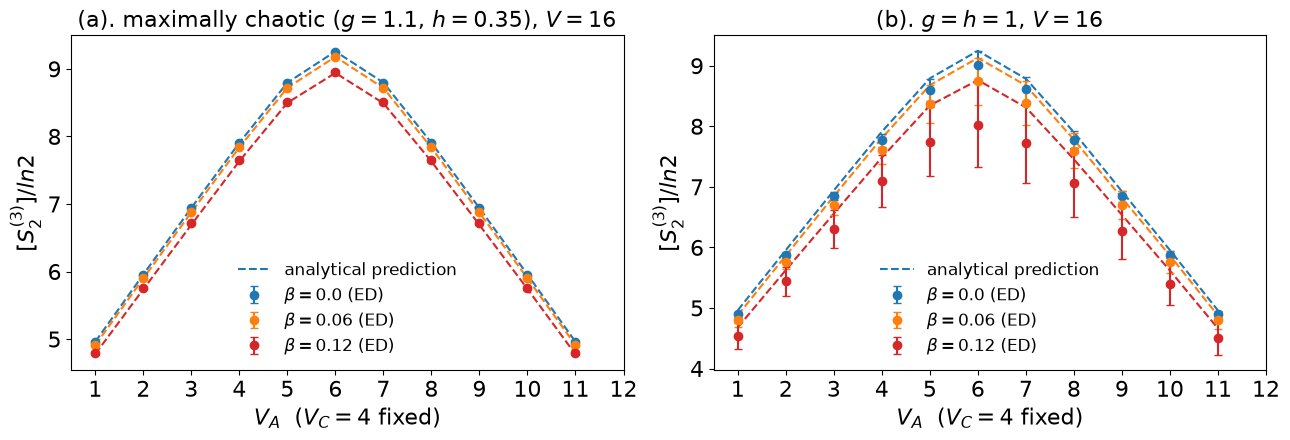

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

for ax, panel in zip(axes, panels):
    for beta in betas:
        VA, S2_mean, S2_err = load_ed_data(panel['folder'], panel['ed_pattern_fn'](beta))
        VA_lead, S2_lead = load_analytical(panel['folder'], panel['analytical_fn'](beta))

        # Leading-order dashed line
        ax.plot(VA_lead, S2_lead, '--', color=colors[beta],
                label='analytical prediction' if beta == betas[0] else None,
                zorder=1)

        # ED data points with error bars
        ax.errorbar(VA, S2_mean, yerr=S2_err, fmt='o', color=colors[beta],
                     label=rf'$\beta={beta}$ (ED)', markersize=6, capsize=3, zorder=2)

    ax.set_xlabel(r'$V_A$  ($V_C = %d$ fixed)' % VC, size = 16)
    ax.set_ylabel(r'$[S_2^{(3)}]/ln2$', size = 16)
    ax.set_title(panel['title'], size=16)
    ax.set_xticks(np.arange(1, V - VC + 1))
    ax.tick_params(axis='both', labelsize=16)
    ax.legend(frameon=False, fontsize=12)

plt.tight_layout()
plt.savefig("fig_3.pdf", dpi=300, bbox_inches='tight')
plt.show()